In [58]:
import os
import sys

import pandas as pd
import numpy as np
import anndata as ad

import tacco as tc
import scanpy as sc
import importlib


In [59]:
#OPTIONAL if reproducing exact plots from submitted manuscript
#SKIP this cell if you are starting from scratch
#revert to UMAP representation previously computed for submitted manuscript
xenium_data_path = "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 5 and S4/xenium_dataset/GEO_submission/anndata_objects"
puck = ad.read_h5ad(f'{xenium_data_path}/adata_tacco_xenium_annotFinal.h5ad')

In [3]:
data_path = './xenium_ctnnd2_vc/data'

In [4]:
#read in spatial data annotated by label transfer
puck = ad.read_h5ad(f'{data_path}/adata_tacco_xenium.h5ad')

## UMAP plots for visualization

In [46]:
# Define the directory to save the UMAP plots
save_dir = './xenium_ctnnd2_vc/umap_plots'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

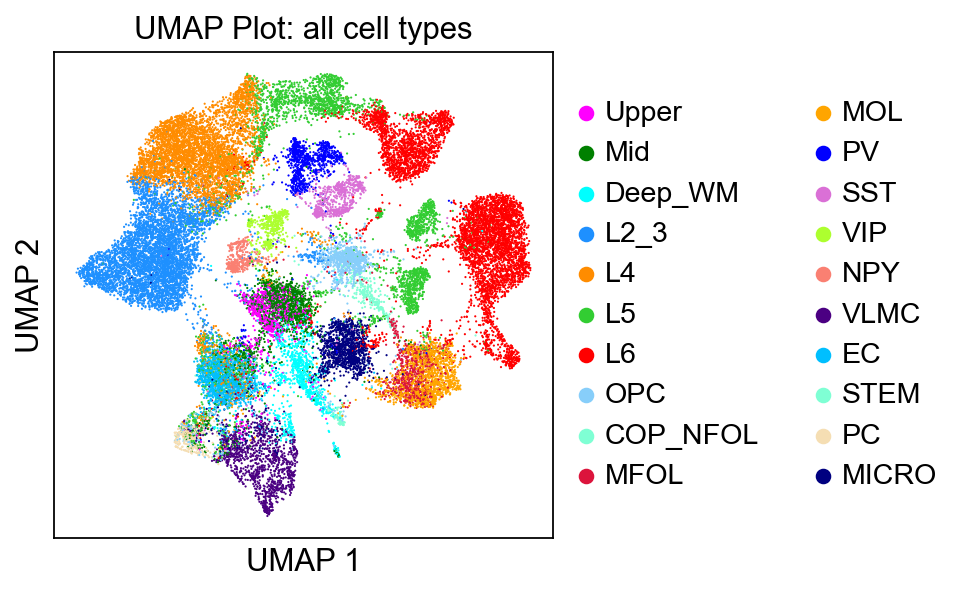

In [47]:
# Plot umap with manual annotations
# Set figure parameters
sc.set_figure_params(transparent=True)

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Desired ordering for the legend
new_order = [
    'Upper', 'Mid', 'Deep_WM', 'L2_3',  'L4', 'L5', 'L6',
    'OPC', 'COP_NFOL', 'MFOL', 'MOL',
    'PV', 'SST', 'VIP', 'NPY',
    'VLMC', 'EC', 'STEM', 'PC', 'MICRO'
]

# Reorder the categories in the AnnData object
puck.obs['predicted_type'] = puck.obs['predicted_type'].cat.reorder_categories(
    new_order,
    ordered=True
)

# your base color dictionary
custom_colors = {
    'Deep_WM': 'cyan',
    'Mid': 'green',
    'Upper': 'magenta',
    'L6': 'red',
    'L5': 'limegreen',
    'L4': 'darkorange',
    'L2_3': 'dodgerblue',
    'MOL': 'orange',
    'COP_NFOL': 'aquamarine',
    'MFOL': 'crimson',
    'OPC': 'lightskyblue', 
    'PV': 'blue',
    'SST': 'orchid',
    'VIP': 'greenyellow',
    'NPY': 'salmon', 
    'VLMC': 'indigo',
    'EC': 'deepskyblue',
    'STEM': 'aquamarine',
    'PC': 'wheat',
    'MICRO': 'navy'
}

# add gray for any missing categories
all_cats = puck.obs['predicted_type'].cat.categories
full_palette = {cat: custom_colors.get(cat, 'lightgray') for cat in all_cats}

# plot
sc.pl.umap(
    puck,
    color="predicted_type",
    palette=full_palette,
    show=False,
    #legend_loc='best'
)

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title('UMAP Plot: all cell types', color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
plt.savefig(f"{save_dir}/tacco_umap_glu_astro_oligo.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\3334453296.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(puck_astro.obs['predicted_type']):


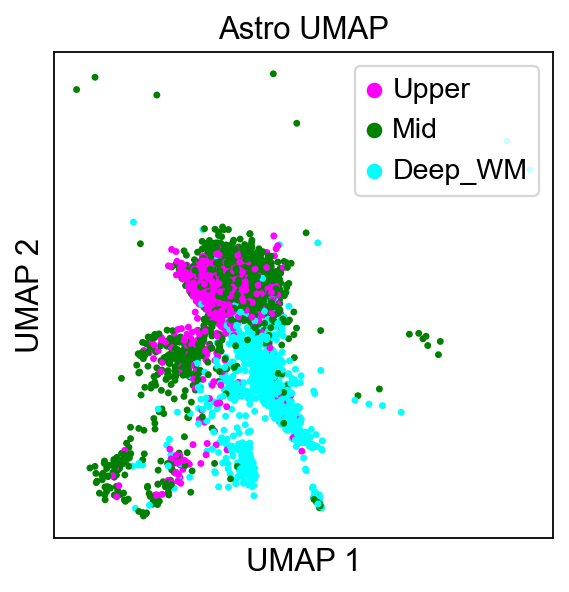

In [48]:
# Filter only desired predicted types
astro_mask = puck.obs['predicted_type'].isin(['Upper', 'Mid', 'Deep_WM'])
puck_astro = puck[astro_mask].copy()

# Define and apply category order safely
astro_order = ['Upper', 'Mid', 'Deep_WM']
if not pd.api.types.is_categorical_dtype(puck_astro.obs['predicted_type']):
    puck_astro.obs['predicted_type'] = pd.Categorical(
        puck_astro.obs['predicted_type'],
        categories=astro_order,
        ordered=True
    )
else:
    puck_astro.obs['predicted_type'] = (
        puck_astro.obs['predicted_type']
        .cat.reorder_categories(astro_order, ordered=True)
    )

# your base color dictionary
custom_colors = {
    'Deep_WM': 'cyan',
    'Mid': 'green',
    'Upper': 'magenta'
}

sc.pl.umap(
puck_astro,
color="predicted_type",
palette=custom_colors,
show=False,
legend_loc='best'
)

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title("Astro UMAP", color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
plt.savefig(f"{save_dir}/tacco_umap_astro_subclusters.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

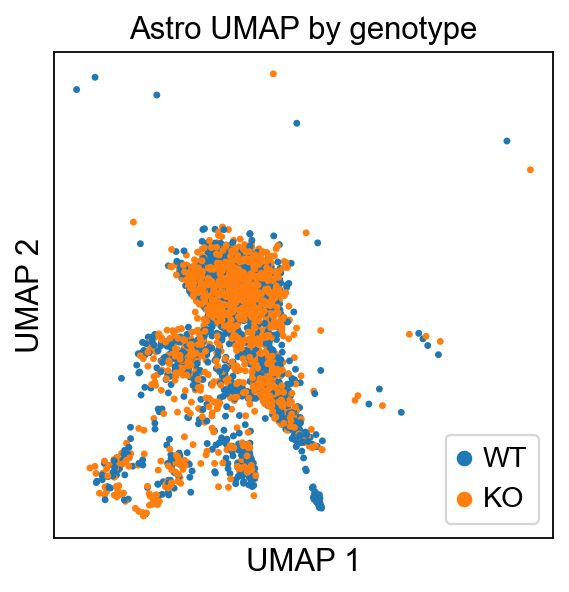

In [49]:
sc.pl.umap(
puck_astro,
color="condition",
show=False,
legend_loc='best'
)

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title("Astro UMAP by genotype", color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
plt.savefig(f"{save_dir}/tacco_umap_astro_genotype.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

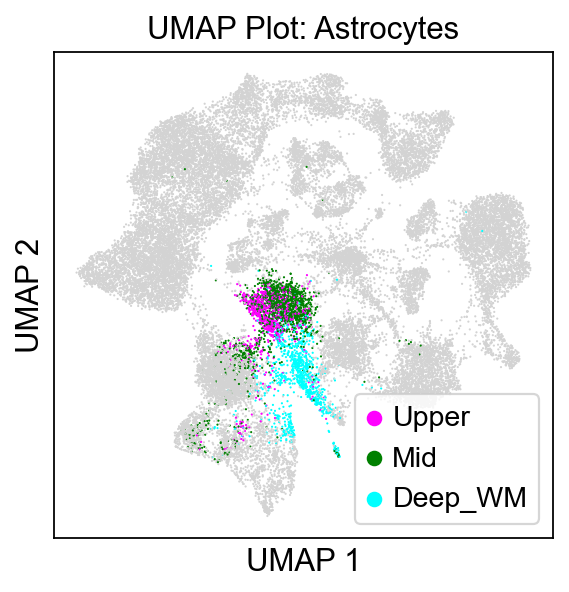

In [50]:
# Plot full UMAP with astrocyte clusters highlighted
# Set figure parameters
sc.set_figure_params(transparent=True)

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Desired ordering for the legend
new_order = [
    'Upper', 'Mid', 'Deep_WM', 'L2_3',  'L4', 'L5', 'L6',
    'OPC', 'COP_NFOL', 'MFOL', 'MOL',
    'PV', 'SST', 'VIP', 'NPY',
    'VLMC', 'EC', 'STEM', 'PC', 'MICRO'
]

# Reorder the categories in the AnnData object
puck.obs['predicted_type'] = puck.obs['predicted_type'].cat.reorder_categories(
    new_order,
    ordered=True
)

# your base color dictionary
custom_colors = {
    'Deep_WM': 'cyan',
    'Mid': 'green',
    'Upper': 'magenta'
}

# add gray for any missing categories
all_cats = puck.obs['predicted_type'].cat.categories
full_palette = {cat: custom_colors.get(cat, 'lightgray') for cat in all_cats}

# plot
sc.pl.umap(
    puck,
    color="predicted_type",
    palette=full_palette,
    show=False,
    #legend_loc='best'
)

ax = plt.gca()
legend = ax.get_legend()

# Change the title font color to white
plt.setp(legend.get_title(), color='black')

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title('UMAP Plot: Astrocytes', color='black')  # Set title color

highlight = ['Upper', 'Mid', 'Deep_WM']

# ---- Get handles safely (patches for Scanpy) ----
try:
    handles = legend.legend_handles
except AttributeError:
    handles = legend.get_patches()

labels = [t.get_text() for t in legend.get_texts()]

# ---- Filter only highlighted clusters ----
filtered = [(h, l) for h, l in zip(handles, labels) if l in highlight]
new_handles, new_labels = zip(*filtered)

# ---- Replace the legend ----
plt.legend(
    new_handles,
    new_labels,
    #bbox_to_anchor=(1.05, 1),
    loc='best'
)


# Save the figure with the legend outside the plot and transparent background
plt.savefig(f"{save_dir}/tacco_umap_astro.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

## Dotplots for visualization

In [51]:
# Define the directory to save the dotplots
save_dir = './xenium_ctnnd2_vc/dotplots'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

C:\Users\Gabrielle\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_dendrogram.py:192: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


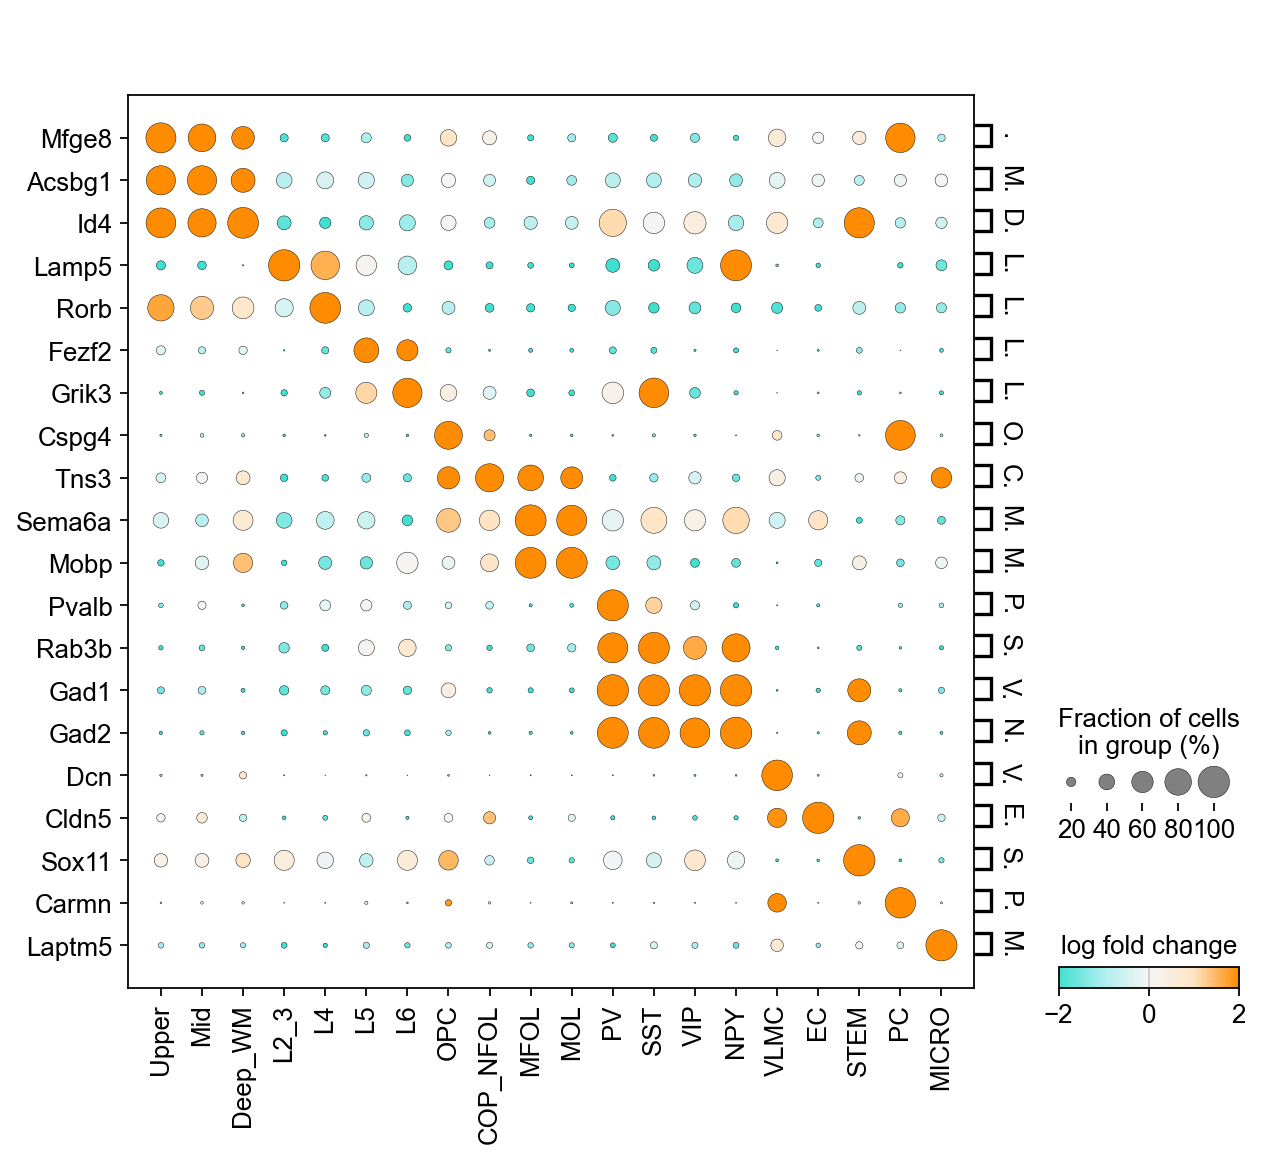

<Figure size 320x320 with 0 Axes>

In [52]:
puck_WT = puck[puck.obs['condition'] == "WT"]

import scanpy as sc
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap

colors = ["turquoise", "paleturquoise", "whitesmoke", "bisque", "darkorange"]
cmap = LinearSegmentedColormap.from_list("darkorange_whitesmoke_turquoise", colors)

sc.tl.dendrogram(puck_WT, groupby="predicted_type")
sc.tl.rank_genes_groups(puck_WT, groupby="predicted_type", method="wilcoxon")

clusters = puck.obs['predicted_type'].cat.categories

sc.pl.rank_genes_groups_dotplot(
    puck_WT, groupby="predicted_type", 
    #standard_scale="var", 
    n_genes = 1, 
    #groups = [cluster],
    values_to_plot="logfoldchanges", 
    cmap = cmap, swap_axes = True, dendrogram = False, show = False, 
    #figsize = (3, 8),
    vmin=-2, vmax=2, dot_max = 1
)
    
# Save the plot to the specified directory
plot_filename = "top_cluster_genes_dotplot_WT.png"  # Generate a unique filename for each cluster
save_path = os.path.join(save_dir, plot_filename)  # Full path to save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save the plot with high resolution

# Show the plot
plt.show()

# Optionally, clear the current figure to avoid overlap in the next loop
plt.clf()

C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\527465767.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  puck_astro_WT.obs["predicted_type"] = puck_astro_WT.obs["predicted_type"].astype('category')


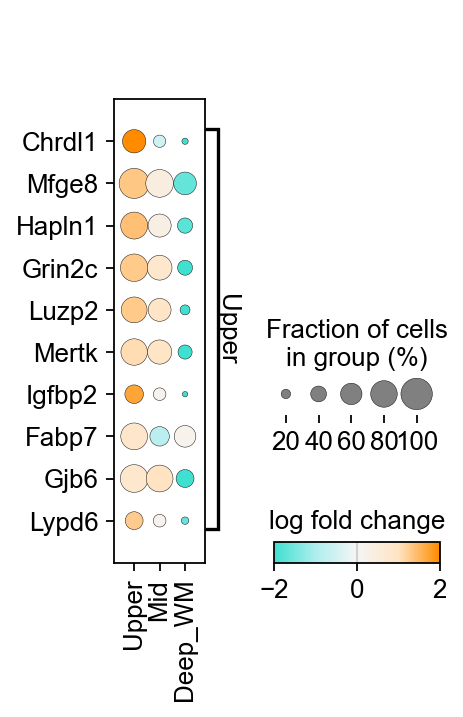

<Figure size 320x320 with 0 Axes>

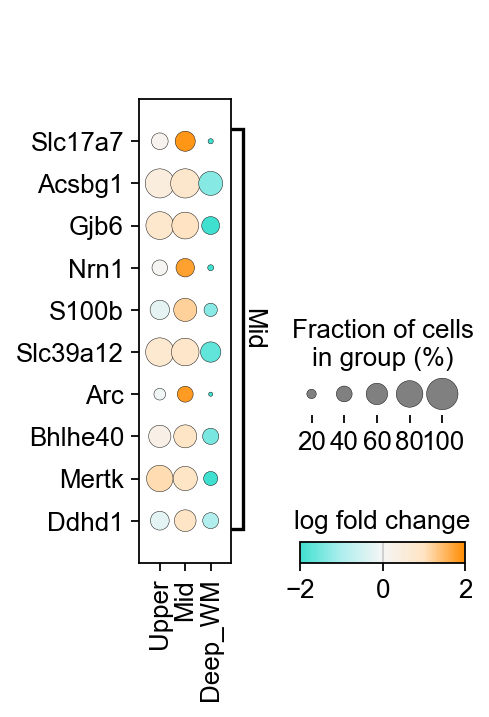

<Figure size 320x320 with 0 Axes>

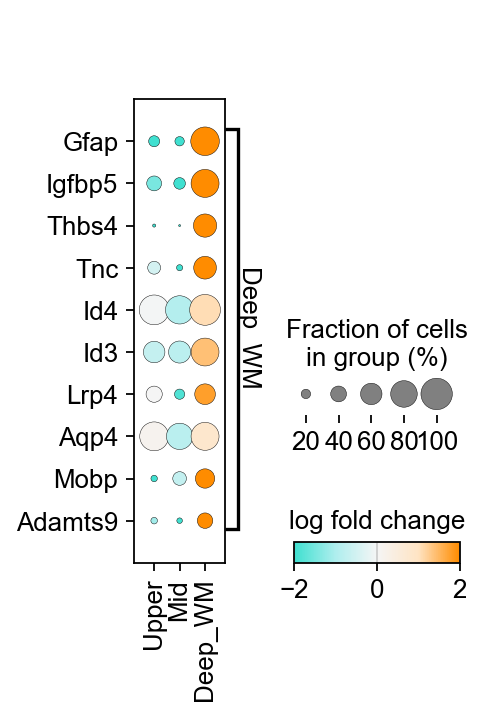

<Figure size 320x320 with 0 Axes>

In [53]:
# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

astro_mask = puck.obs['predicted_type'].isin(['Upper', 'Mid', 'Deep_WM'])
puck_astro = puck[astro_mask]
puck_astro_WT = puck_astro[puck_astro.obs['condition'] == "WT"]

# Convert 'cluster_id' to categorical type (if not already)
puck_astro_WT.obs["predicted_type"] = puck_astro_WT.obs["predicted_type"].astype('category')

# Reorder the categories in 'cluster_id' so that 'Upper' comes first
layer_order = ["Upper", "Mid", "Deep_WM"]
puck_astro_WT.obs["predicted_type"] = puck_astro_WT.obs["predicted_type"].cat.reorder_categories(layer_order)

import scanpy as sc
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap

colors = ["turquoise", "paleturquoise", "whitesmoke", "bisque", "darkorange"]
cmap = LinearSegmentedColormap.from_list("darkorange_whitesmoke_turquoise", colors)

sc.tl.dendrogram(puck_astro_WT, groupby="predicted_type")
sc.tl.rank_genes_groups(puck_astro_WT, groupby="predicted_type", method="wilcoxon")

clusters = puck_astro_WT.obs['predicted_type'].cat.categories

for cluster in clusters:
    sc.pl.rank_genes_groups_dotplot(
        puck_astro_WT, groupby="predicted_type", 
        #standard_scale="var", 
        n_genes = 10, 
        groups = [cluster],
        values_to_plot="logfoldchanges", 
        cmap = cmap, swap_axes = True, dendrogram = False, show = False, 
        #figsize = (3, 8),
        vmin=-2, vmax=2, dot_max = 1
    )
    
    # Save the plot to the specified directory
    plot_filename = f"top_layer_genes_{cluster}_dotplot_WT.png"  # Generate a unique filename for each cluster
    save_path = os.path.join(save_dir, plot_filename)  # Full path to save the plot
    plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save the plot with high resolution
    
    # Show the plot
    plt.show()
    
    # Optionally, clear the current figure to avoid overlap in the next loop
    plt.clf()

In [54]:
result = puck_astro_WT.uns["rank_genes_groups"]
groups = result["names"].dtype.names
layer_results = pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names", "scores", "logfoldchanges", "pvals_adj"]
    }
)
layer_results.to_csv(f'{save_dir}/astro_layer_enriched_xenium.csv')

## Subtype counts for GLU, GABA, OLIGO, ASTRO major clusters

In [55]:
# Define the directory to save the counts csvs
save_dir = './xenium_ctnnd2_vc/subtype_counts'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# Define masks for each condition
astro_mask_1M = puck_astro.obs['sample_id'] == '1M_KO'
astro_mask_8M = puck_astro.obs['sample_id'] == '8M_WT'
astro_mask_2F = puck_astro.obs['sample_id'] == '2F_WT'
astro_mask_7F = puck_astro.obs['sample_id'] == '7F_KO'
astro_mask_WT = puck_astro.obs['condition'] == 'WT'
astro_mask_KO = puck_astro.obs['condition'] == 'KO'

# Subset AnnData objects
puck_astro_1M = puck_astro[astro_mask_1M].copy()
puck_astro_8M = puck_astro[astro_mask_8M].copy()
puck_astro_2F = puck_astro[astro_mask_2F].copy()
puck_astro_7F = puck_astro[astro_mask_7F].copy()
puck_astro_WT = puck_astro[astro_mask_WT].copy()
puck_astro_KO = puck_astro[astro_mask_KO].copy()

# Combine value counts for all subsets
counts = pd.DataFrame({
    'astro_1M': puck_astro_1M.obs['predicted_type'].value_counts().reindex(astro_order),
    'astro_8M': puck_astro_8M.obs['predicted_type'].value_counts().reindex(astro_order),
    'astro_2F': puck_astro_2F.obs['predicted_type'].value_counts().reindex(astro_order),
    'astro_7F': puck_astro_7F.obs['predicted_type'].value_counts().reindex(astro_order)
}).fillna(0).astype(int)

print(counts)
counts.to_csv(f'{save_dir}/astro_subtype_counts.csv')

                astro_1M  astro_8M  astro_2F  astro_7F
predicted_type                                        
Upper                214       165       182       182
Mid                  474       333       390       262
Deep_WM              247       265       241       162


In [57]:
# Create mask to filter specific predicted types
glu_mask = puck.obs['predicted_type'].isin(['L2_3', 'L4', 'L5', 'L6'])

puck_glu = puck[glu_mask]
glu_order = ['L2_3', 'L4', 'L5', 'L6']
if not pd.api.types.is_categorical_dtype(puck_glu.obs['predicted_type']):
    puck_glu.obs['predicted_type'] = pd.Categorical(
        puck_glu.obs['predicted_type'],
        categories=glu_order,
        ordered=True
    )
else:
    puck_glu.obs['predicted_type'] = (
        puck_glu.obs['predicted_type']
        .cat.reorder_categories(glu_order, ordered=True)
    )

glu_mask_1M = puck_glu.obs['sample_id'].isin(['1M_KO'])
glu_mask_8M = puck_glu.obs['sample_id'].isin(['8M_WT'])
glu_mask_2F = puck_glu.obs['sample_id'].isin(['2F_WT'])
glu_mask_7F = puck_glu.obs['sample_id'].isin(['7F_KO'])
glu_mask_WT = puck_glu.obs['condition'].isin(['WT'])
glu_mask_KO = puck_glu.obs['condition'].isin(['KO'])

# Subset AnnData
puck_glu_1M = puck_glu[glu_mask_1M].copy()
puck_glu_8M = puck_glu[glu_mask_8M].copy()
puck_glu_2F = puck_glu[glu_mask_2F].copy()
puck_glu_7F = puck_glu[glu_mask_7F].copy()
puck_glu_WT = puck_glu[glu_mask_WT].copy()
puck_glu_KO = puck_glu[glu_mask_KO].copy()

# Collect value_counts from each dataset
counts = pd.DataFrame({
    'glu_1M': puck_glu_1M.obs['predicted_type'].value_counts().reindex(glu_order),
    'glu_8M': puck_glu_8M.obs['predicted_type'].value_counts().reindex(glu_order),
    'glu_2F': puck_glu_2F.obs['predicted_type'].value_counts().reindex(glu_order),
    'glu_7F': puck_glu_7F.obs['predicted_type'].value_counts().reindex(glu_order)
}).fillna(0).astype(int)  # Fill missing clusters with 0

print(counts)
counts.to_csv(f'{save_dir}/glu_subtype_counts.csv')

C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\1606865520.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(puck_glu.obs['predicted_type']):
C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\1606865520.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  puck_glu.obs['predicted_type'] = (


                glu_1M  glu_8M  glu_2F  glu_7F
predicted_type                                
L2_3              1617    1119    1311    1188
L4                1786     810    1107     823
L5                 958     817     737     602
L6                1948    1137    1342     962


In [19]:
# Create mask to filter specific predicted types
oligo_mask = puck.obs['predicted_type'].isin(['OPC', 'COP_NFOL', 'MFOL', 'MOL'])
puck_oligo = puck[oligo_mask]

oligo_order = ['OPC', 'COP_NFOL', 'MFOL', 'MOL']
if not pd.api.types.is_categorical_dtype(puck_oligo.obs['predicted_type']):
    puck_oligo.obs['predicted_type'] = pd.Categorical(
        puck_oligo.obs['predicted_type'],
        categories=oligo_order,
        ordered=True
    )
else:
    puck_oligo.obs['predicted_type'] = (
        puck_oligo.obs['predicted_type']
        .cat.reorder_categories(oligo_order, ordered=True)
    )
    
oligo_mask_1M = puck_oligo.obs['sample_id'].isin(['1M_KO'])
oligo_mask_8M = puck_oligo.obs['sample_id'].isin(['8M_WT'])
oligo_mask_2F = puck_oligo.obs['sample_id'].isin(['2F_WT'])
oligo_mask_7F = puck_oligo.obs['sample_id'].isin(['7F_KO'])
oligo_mask_WT = puck_oligo.obs['condition'].isin(['WT'])
oligo_mask_KO = puck_oligo.obs['condition'].isin(['KO'])

# Subset AnnData
puck_oligo_1M = puck_oligo[oligo_mask_1M]
puck_oligo_8M = puck_oligo[oligo_mask_8M]
puck_oligo_2F = puck_oligo[oligo_mask_2F]
puck_oligo_7F = puck_oligo[oligo_mask_7F]
puck_oligo_WT = puck_oligo[oligo_mask_WT]
puck_oligo_KO = puck_oligo[oligo_mask_KO]

# Collect value_counts from each dataset
counts = pd.DataFrame({
    'oligo_1M': puck_oligo_1M.obs['predicted_type'].value_counts().reindex(oligo_order),
    'oligo_8M': puck_oligo_8M.obs['predicted_type'].value_counts().reindex(oligo_order),
    'oligo_2F': puck_oligo_2F.obs['predicted_type'].value_counts().reindex(oligo_order),
    'oligo_7F': puck_oligo_7F.obs['predicted_type'].value_counts().reindex(oligo_order)
}).fillna(0).astype(int)  # Fill missing clusters with 0

print(counts)
counts.to_csv(f'{save_dir}/oligo_subtype_counts.csv')

                oligo_1M  oligo_8M  oligo_2F  oligo_7F
predicted_type                                        
OPC                  321       251       292       183
COP_NFOL              93        66       110        70
MFOL                 187       153       188       131
MOL                  501       352       438       202


C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\307882918.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(puck_oligo.obs['predicted_type']):
C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\307882918.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  puck_oligo.obs['predicted_type'] = (


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter only desired predicted types
intn_mask = puck.obs['predicted_type'].isin(['PV', 'SST', 'VIP', 'NPY'])
puck_intn = puck[intn_mask].copy()

# Define and apply category order safely
intn_order = ['PV', 'SST', 'VIP', 'NPY']
if not pd.api.types.is_categorical_dtype(puck_intn.obs['predicted_type']):
    puck_intn.obs['predicted_type'] = pd.Categorical(
        puck_intn.obs['predicted_type'],
        categories=intn_order,
        ordered=True
    )
else:
    puck_intn.obs['predicted_type'] = (
        puck_intn.obs['predicted_type']
        .cat.reorder_categories(intn_order, ordered=True)
    )

# Define masks for each condition
intn_mask_1M = puck_intn.obs['sample_id'] == '1M_KO'
intn_mask_8M = puck_intn.obs['sample_id'] == '8M_WT'
intn_mask_2F = puck_intn.obs['sample_id'] == '2F_WT'
intn_mask_7F = puck_intn.obs['sample_id'] == '7F_KO'
intn_mask_WT = puck_intn.obs['condition'] == 'WT'
intn_mask_KO = puck_intn.obs['condition'] == 'KO'

# Subset AnnData objects
puck_intn_1M = puck_intn[intn_mask_1M].copy()
puck_intn_8M = puck_intn[intn_mask_8M].copy()
puck_intn_2F = puck_intn[intn_mask_2F].copy()
puck_intn_7F = puck_intn[intn_mask_7F].copy()
puck_intn_WT = puck_intn[intn_mask_WT].copy()
puck_intn_KO = puck_intn[intn_mask_KO].copy()

# Combine value counts for all subsets
counts = pd.DataFrame({
    'intn_1M': puck_intn_1M.obs['predicted_type'].value_counts().reindex(intn_order),
    'intn_8M': puck_intn_8M.obs['predicted_type'].value_counts().reindex(intn_order),
    'intn_2F': puck_intn_2F.obs['predicted_type'].value_counts().reindex(intn_order),
    'intn_7F': puck_intn_7F.obs['predicted_type'].value_counts().reindex(intn_order)
}).fillna(0).astype(int)

print(counts)
counts.to_csv(f'{save_dir}/intn_subtype_counts.csv')


                intn_1M  intn_8M  intn_2F  intn_7F
predicted_type                                    
PV                  307      215      222      170
SST                 202      156      176      140
VIP                 137      102      128       83
NPY                  99       80      104       66


C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_28080\3977626216.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(puck_intn.obs['predicted_type']):


## KO v WT astrocyte DEGs

In [21]:
# Define the directory to save the DEG lists
save_dir = './xenium_ctnnd2_vc/DEG_tables'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

In [22]:
sc.tl.rank_genes_groups(puck_astro, groupby="condition", method="wilcoxon", reference = 'WT')
result = puck_astro.uns["rank_genes_groups"]
groups = result["names"].dtype.names
grouped_results = pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names", "scores", "logfoldchanges", "pvals_adj"]
    }
)
grouped_results.to_csv(f'{save_dir}/astro_Wilcoxon_results_xenium.csv')

C:\Users\Gabrielle\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [23]:
# Sort by KO_s (wilcoxon score) descending
df_sorted = grouped_results.sort_values(by="KO_s", ascending=False)
# Get top 10 upregulated (highest KO_l)
top20_up = df_sorted.head(20)["KO_n"].tolist()

# Get top 10 downregulated (lowest KO_l)
top20_down = df_sorted.tail(20)["KO_n"].tolist()

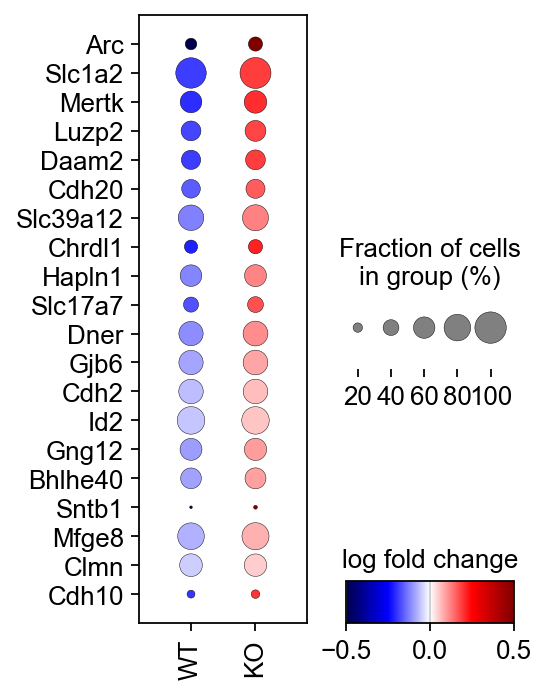

<Figure size 320x320 with 0 Axes>

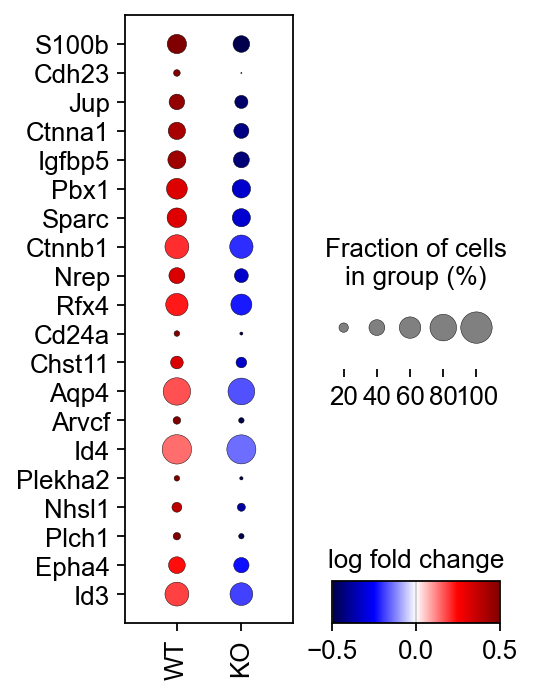

<Figure size 320x320 with 0 Axes>

In [26]:
# Convert 'cluster_id' to categorical type (if not already)
puck_astro.obs["condition"] = puck_astro.obs["condition"].astype('category')

# Reorder the categories in 'cluster_id' so that 'Upper' comes first
genotype_order = ["WT", "KO"]
puck_astro.obs["condition"] = puck_astro.obs["condition"].cat.reorder_categories(genotype_order)

import scanpy as sc
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap

sc.tl.rank_genes_groups(puck_astro, groupby="condition", method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(
    puck_astro, groupby="condition", 
    var_names = top20_up, 
    dot_max = 1,
    values_to_plot="logfoldchanges", 
    cmap = 'seismic', swap_axes = True, dendrogram = False, show = False, figsize = (3, 5),
    vmin=-0.5, vmax=0.5
)

# Save the plot to the specified directory
plot_filename = "KOvWT_upreg_dotplot_astro.png"  # Generate a unique filename for each cluster
save_path = os.path.join(save_dir, plot_filename)  # Full path to save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save the plot with high resolution

# Show the plot
plt.show()

# Optionally, clear the current figure to avoid overlap in the next loop
plt.clf()


top20_down.reverse()
sc.pl.rank_genes_groups_dotplot(
    puck_astro, groupby="condition", 
    #standard_scale="var", 
    var_names = top20_down, 
    dot_max = 1,
    values_to_plot="logfoldchanges", 
    cmap = 'seismic', swap_axes = True, dendrogram = False, show = False, figsize = (3, 5),
    vmin=-0.5, vmax=0.5
)

# Save the plot to the specified directory
plot_filename = "KOvWT_downreg_dotplot_astro.png"  # Generate a unique filename for each cluster
save_path = os.path.join(save_dir, plot_filename)  # Full path to save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save the plot with high resolution

# Show the plot
plt.show()

# Optionally, clear the current figure to avoid overlap in the next loop
plt.clf()

In [28]:
# create lists of layer-enriched genes and check for overlap with DEGs
# subset by layer of enrichment
upper_enriched = layer_results.filter(like='Upper')
mid_enriched = layer_results.filter(like='Mid')
deepWM_enriched = layer_results.filter(like='Deep_WM')

# Set p-value and fold change cutoffs
upper_enriched = upper_enriched[(upper_enriched['Upper_l'] > 0.85) & (upper_enriched['Upper_p'] < 0.05)]['Upper_n'].tolist()
mid_enriched = mid_enriched[(mid_enriched['Mid_l'] > 0.85) & (mid_enriched['Mid_p'] < 0.05)]['Mid_n'].tolist()
deepWM_enriched = deepWM_enriched[(deepWM_enriched['Deep_WM_l'] > 0.85) & (deepWM_enriched['Deep_WM_p'] < 0.05)]['Deep_WM_n'].tolist()

# cross-reference layer-enriched genes with DEGs
upreg_upper = np.intersect1d(top20_up, upper_enriched)
upreg_mid = np.intersect1d(top20_up, mid_enriched)
upreg_deepWM = np.intersect1d(top20_up, deepWM_enriched)
print(upreg_upper, upreg_mid, upreg_deepWM)

downreg_upper = np.intersect1d(top20_down, upper_enriched)
downreg_mid = np.intersect1d(top20_down, mid_enriched)
downreg_deepWM = np.intersect1d(top20_down, deepWM_enriched)
print(downreg_upper, downreg_mid, downreg_deepWM)

['Cdh10' 'Chrdl1' 'Hapln1' 'Luzp2' 'Mertk' 'Mfge8'] ['Arc' 'Bhlhe40' 'Gjb6' 'Luzp2' 'Mertk' 'Slc17a7' 'Slc39a12'] []
[] ['Nhsl1' 'S100b'] ['Arvcf' 'Cd24a' 'Cdh23' 'Id3' 'Id4' 'Igfbp5' 'Plekha2']


## Column plots for visualization

In [33]:
# Define the directory to save the DEG lists
save_dir = './xenium_ctnnd2_vc/column_plots'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

In [34]:
import pandas as pd

# Load selected cells
select_cells = pd.read_csv(f'{data_path}/2F_column_final.csv', skiprows=2)

# Boolean mask for cells in 2F_WT sample
mask_sample = puck.obs['sample_id'] == '2F_WT'

# Boolean mask for cells in your CSV
mask_cells = puck.obs['cell_id'].isin(select_cells["Cell ID"])

# Combine masks
mask = mask_sample & mask_cells

# Subset the AnnData object
subset_2F = puck[mask].copy()


C:\Users\Gabrielle\Documents\GitHub\tacco\tacco\plots\_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
C:\Users\Gabrielle\anaconda3\envs\tacco_env\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


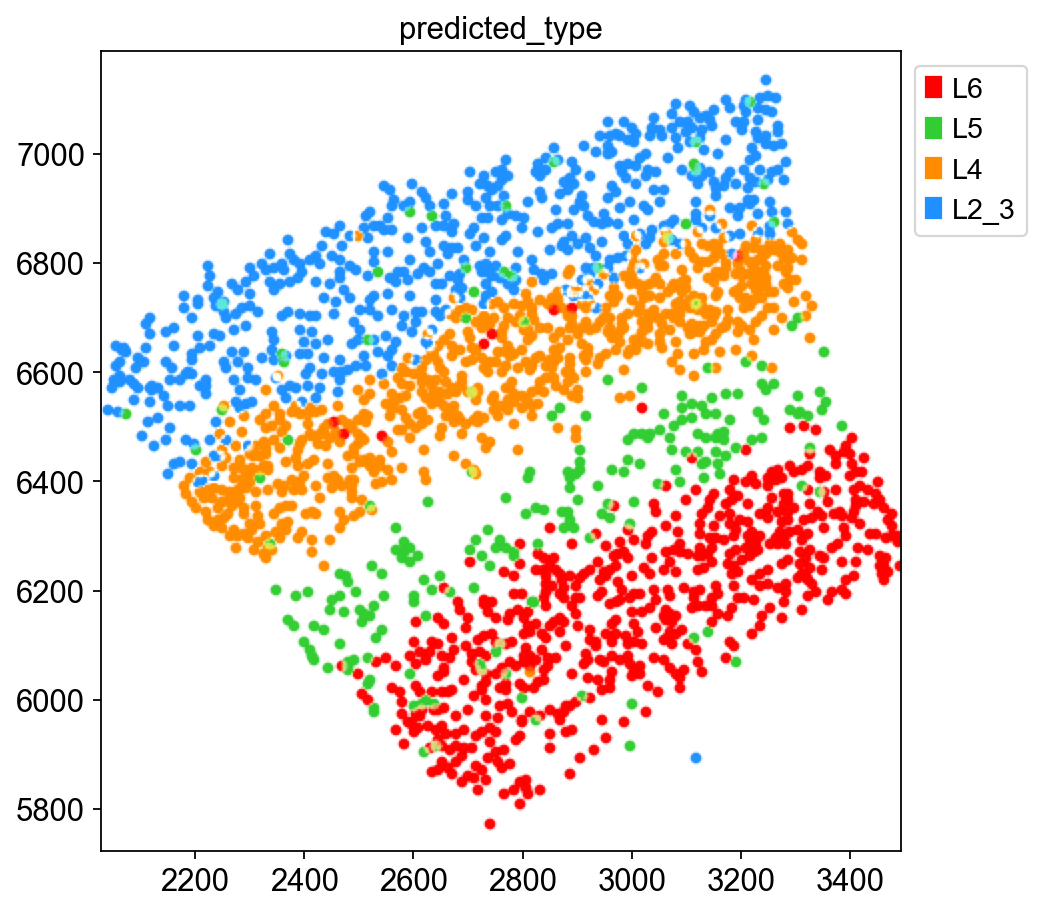

In [35]:
import matplotlib.pyplot as plt

glu_mask = subset_2F.obs['predicted_type'].isin(['L2_3', 'L4', 'L5', 'L6'])
subset_2F_glu = subset_2F[glu_mask]

custom_colors = {
    'L6': 'red',
    'L5': 'limegreen',
    'L4': 'darkorange',
    'L2_3': 'dodgerblue'
}

# Plot with custom colors
fig = tc.pl.scatter(
    subset_2F_glu,
    keys=('predicted_type',),
    position_key='spatial',
    point_size=20,
    colors=custom_colors  # <- custom colors here
)

plt.savefig(f"{save_dir}/tacco_glu_2F_WT.png", dpi=800, bbox_inches='tight')

plt.show()

C:\Users\Gabrielle\Documents\GitHub\tacco\tacco\plots\_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
C:\Users\Gabrielle\anaconda3\envs\tacco_env\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


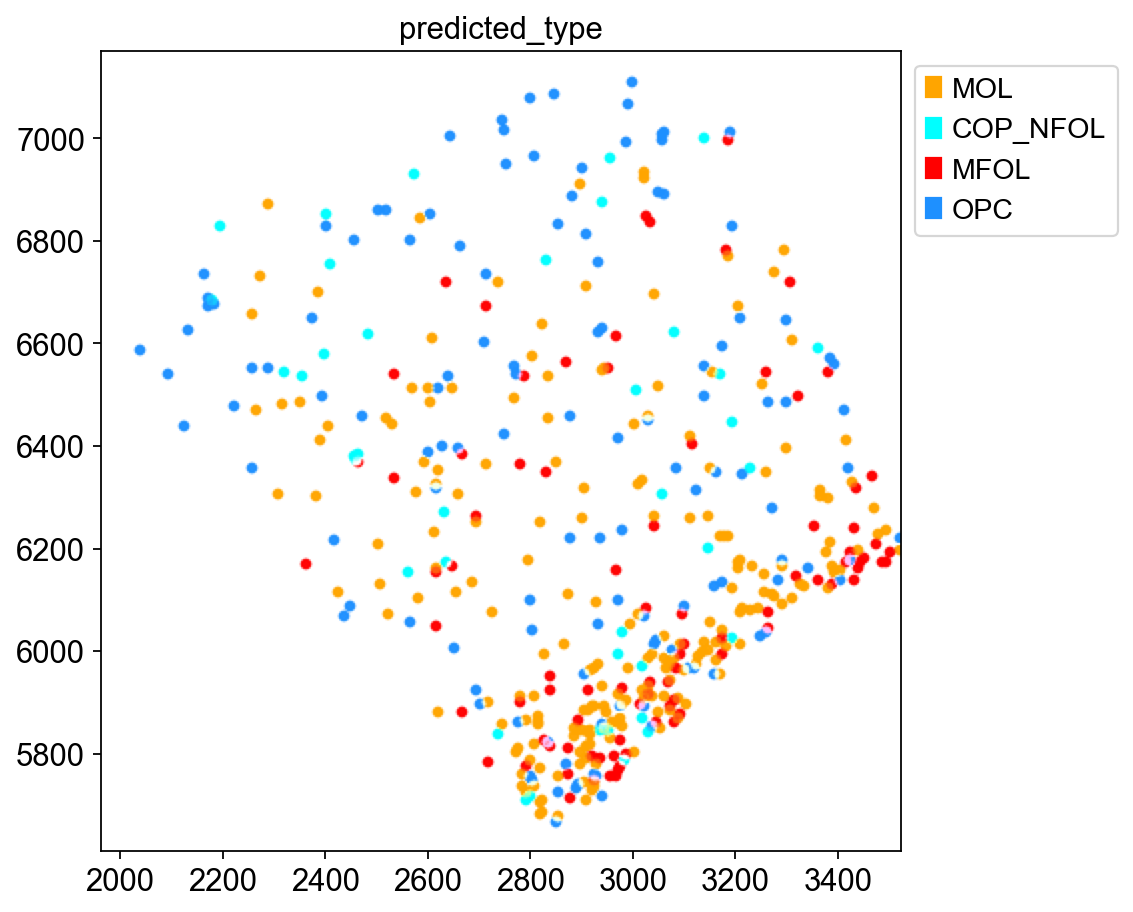

In [37]:
import matplotlib.pyplot as plt

oligo_mask = subset_2F.obs['predicted_type'].isin(['MOL', 'COP_NFOL', 'MFOL', 'OPC'])
subset_2F_oligo = subset_2F[oligo_mask]

custom_colors = {
    'MOL': 'orange',
    'COP_NFOL': 'aqua',
    'MFOL': 'red',
    'OPC': 'dodgerblue', 
}

# Plot with custom colors
fig = tc.pl.scatter(
    subset_2F_oligo,
    keys=('predicted_type',),
    position_key='spatial',
    point_size=20,
    colors=custom_colors  # <- custom colors here
)

plt.savefig(f"{save_dir}/tacco_oligo_2F_WT.png", dpi=800, bbox_inches='tight')

plt.show()

C:\Users\Gabrielle\Documents\GitHub\tacco\tacco\plots\_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
C:\Users\Gabrielle\anaconda3\envs\tacco_env\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


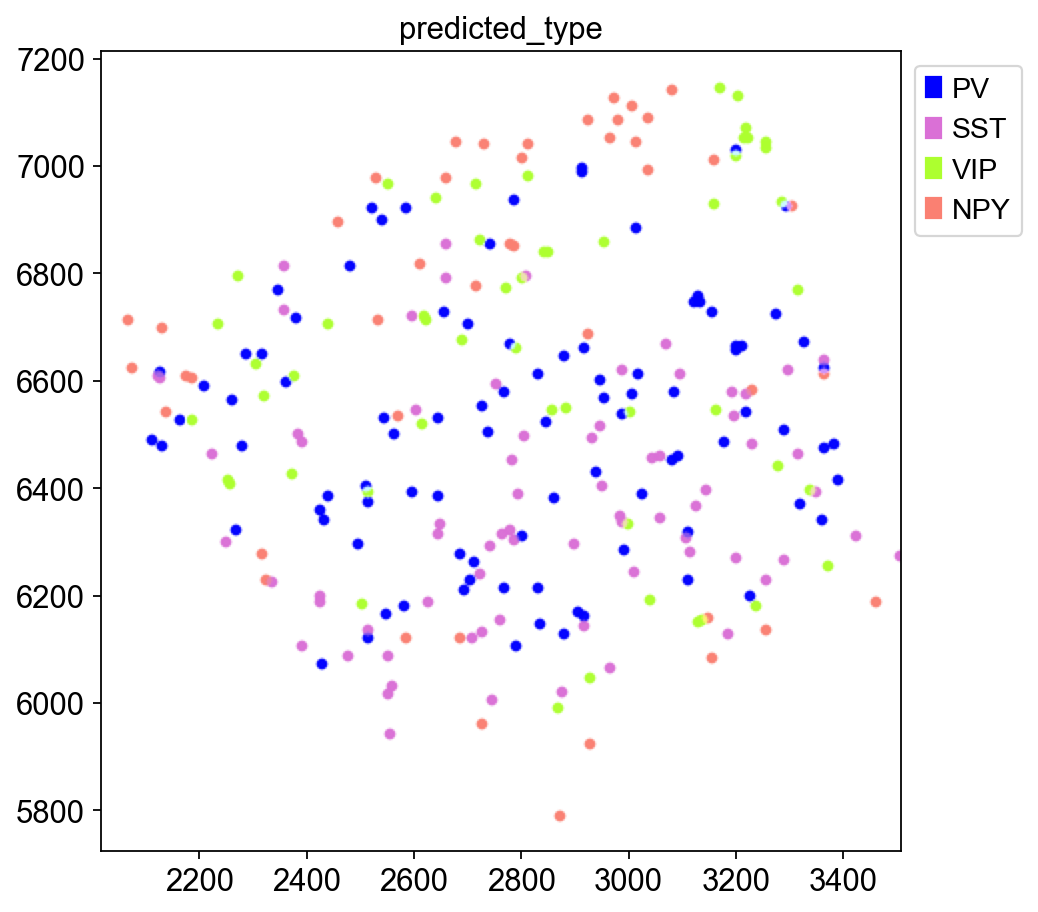

In [38]:
import matplotlib.pyplot as plt

intn_mask = subset_2F.obs['predicted_type'].isin(['PV', 'SST', 'VIP', 'NPY'])
subset_2F_intn = subset_2F[intn_mask]

custom_colors = {
    'PV': 'blue',
    'SST': 'orchid',
    'VIP': 'greenyellow',
    'NPY': 'salmon'
}

# Plot with custom colors
fig = tc.pl.scatter(
    subset_2F_intn,
    keys=('predicted_type',),
    position_key='spatial',
    point_size=20,
    colors=custom_colors  # <- custom colors here
)

plt.savefig(f"{save_dir}/tacco_intn_2F_WT.png", dpi=800, bbox_inches='tight')

plt.show()

In [39]:
import pandas as pd

# Load selected cells
select_cells = pd.read_csv(f'{data_path}/7F_column_final.csv', skiprows=2)

# Boolean mask for cells in 7F_WT sample
mask_sample = puck.obs['sample_id'] == '7F_KO'

# Boolean mask for cells in your CSV
mask_cells = puck.obs['cell_id'].isin(select_cells["Cell ID"])

# Combine masks
mask = mask_sample & mask_cells

# Subset the AnnData object
subset_7F = puck[mask].copy()


C:\Users\Gabrielle\Documents\GitHub\tacco\tacco\plots\_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
C:\Users\Gabrielle\anaconda3\envs\tacco_env\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


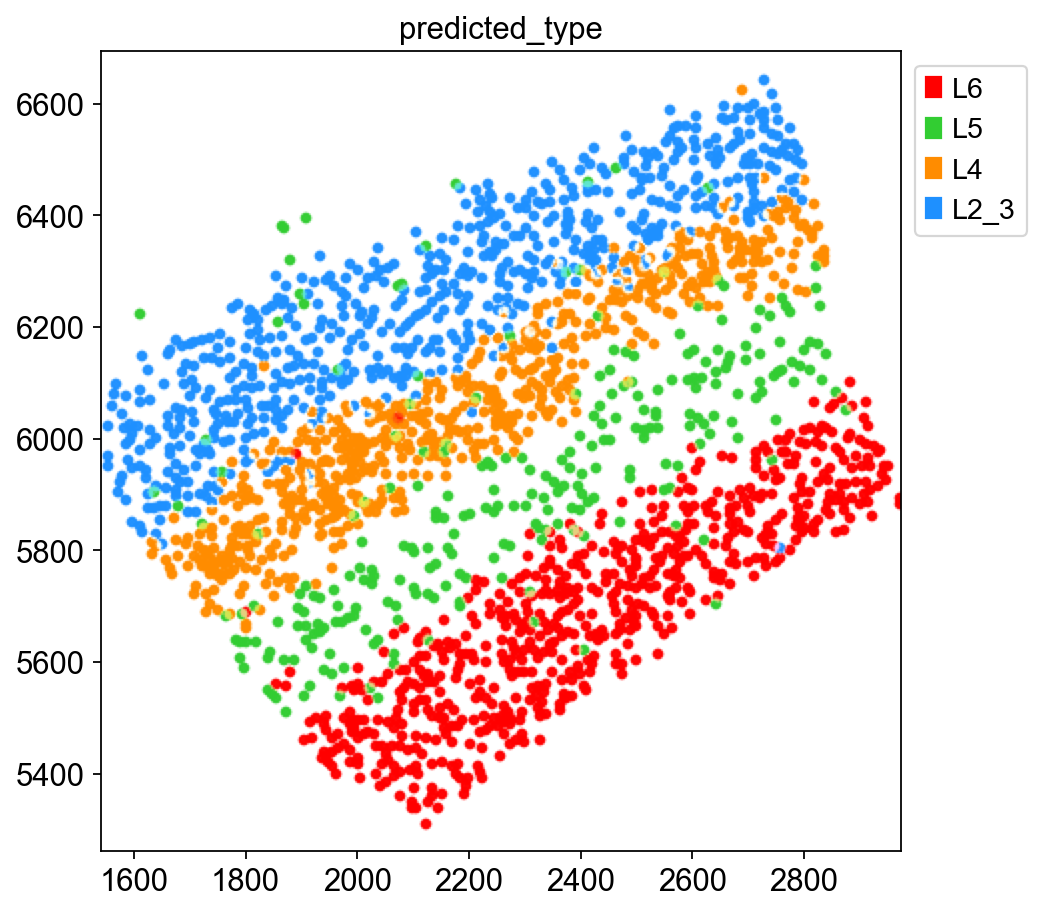

In [40]:
import matplotlib.pyplot as plt

glu_mask = subset_7F.obs['predicted_type'].isin(['L2_3', 'L4', 'L5', 'L6'])
subset_7F_glu = subset_7F[glu_mask]

#Define custom colors for each predicted_type
custom_colors = {
    'L6': 'red',
    'L5': 'limegreen',
    'L4': 'darkorange',
    'L2_3': 'dodgerblue'
}

# Plot with custom colors
fig = tc.pl.scatter(
    subset_7F_glu,
    keys=('predicted_type',),
    position_key='spatial',
    point_size=20,
    colors=custom_colors  # <- custom colors here
)

plt.savefig(f"{save_dir}/tacco_glu_7F_KO.png", dpi=800, bbox_inches='tight')

plt.show()

C:\Users\Gabrielle\Documents\GitHub\tacco\tacco\plots\_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
C:\Users\Gabrielle\anaconda3\envs\tacco_env\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


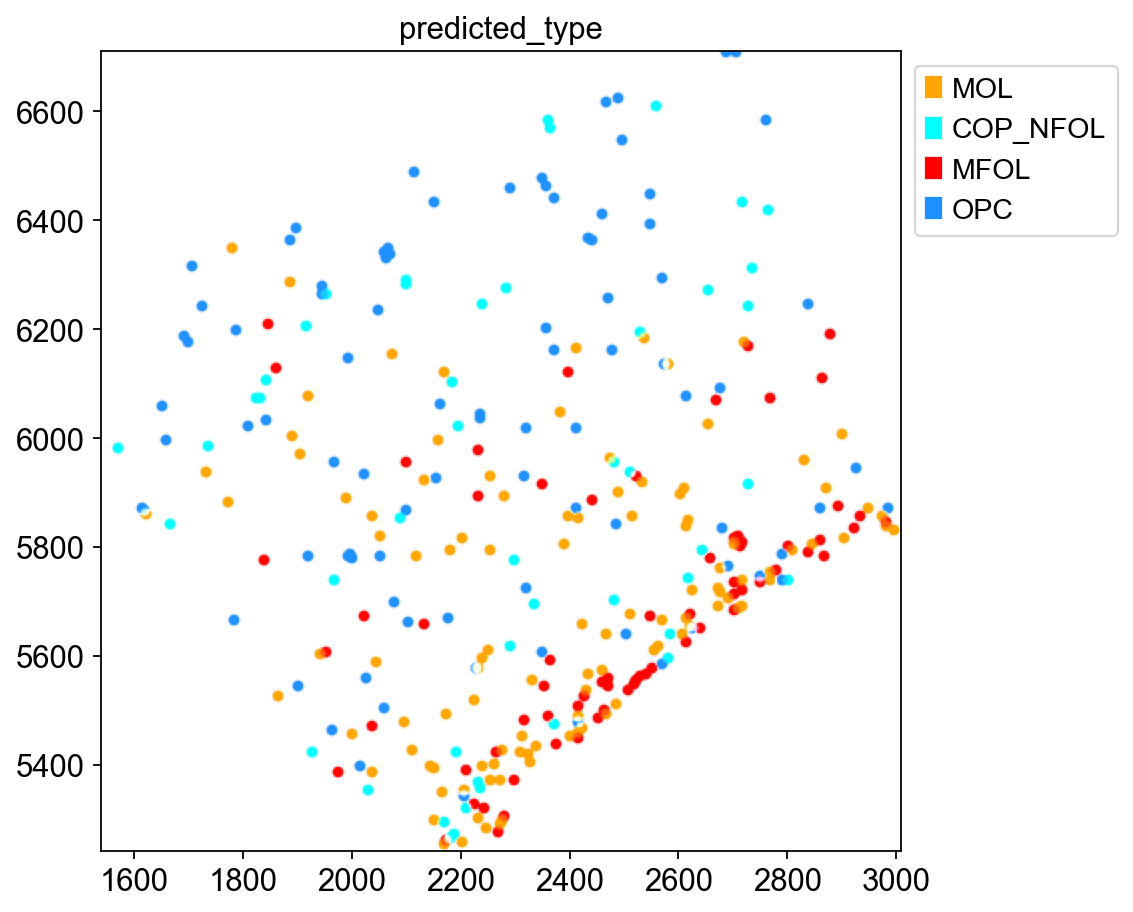

In [42]:
import matplotlib.pyplot as plt

oligo_mask = subset_7F.obs['predicted_type'].isin(['MOL', 'COP_NFOL', 'MFOL', 'OPC'])
subset_7F_oligo = subset_7F[oligo_mask]

custom_colors = {
    'MOL': 'orange',
    'COP_NFOL': 'aqua',
    'MFOL': 'red',
    'OPC': 'dodgerblue', 
}

# Plot with custom colors
fig = tc.pl.scatter(
    subset_7F_oligo,
    keys=('predicted_type',),
    position_key='spatial',
    point_size=20,
    colors=custom_colors  # <- custom colors here
)

plt.savefig(f"{save_dir}/tacco_oligo_7F_KO.png", dpi=800, bbox_inches='tight')

plt.show()

C:\Users\Gabrielle\Documents\GitHub\tacco\tacco\plots\_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
C:\Users\Gabrielle\anaconda3\envs\tacco_env\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


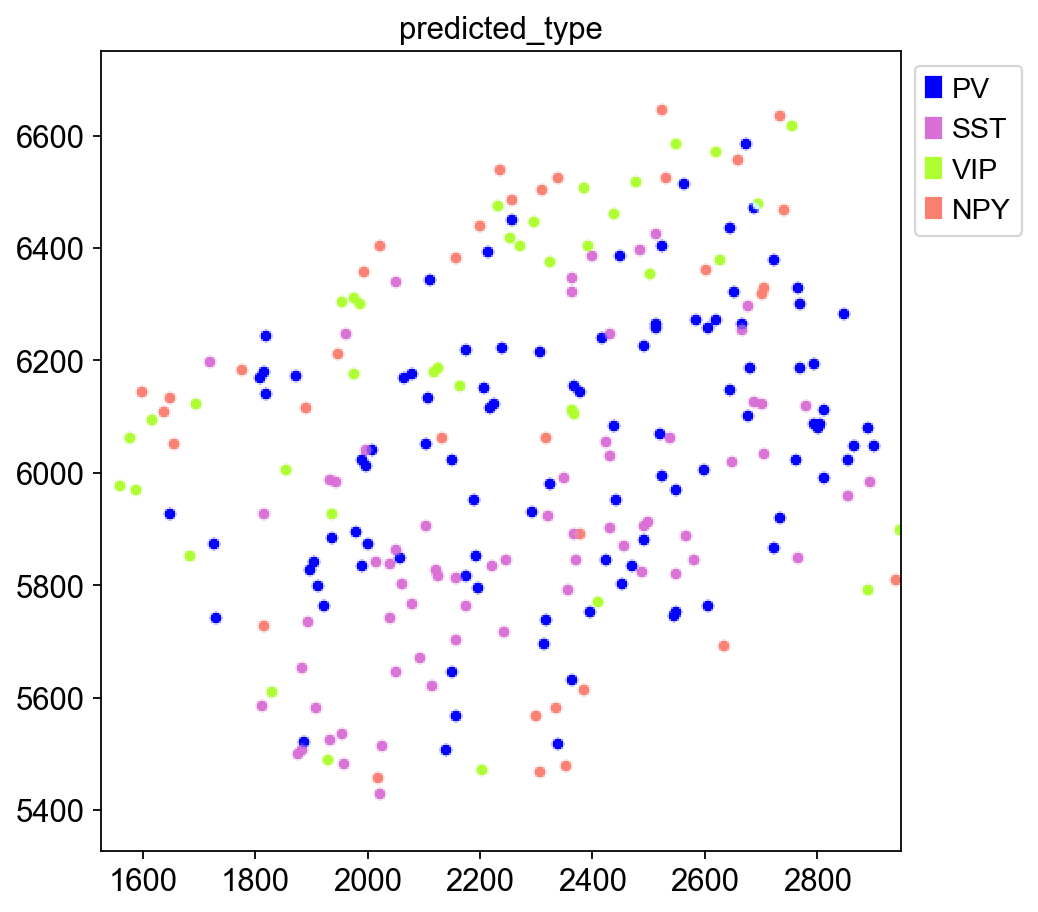

In [43]:
import matplotlib.pyplot as plt

intn_mask = subset_7F.obs['predicted_type'].isin(['PV', 'SST', 'VIP', 'NPY'])
subset_7F_intn = subset_7F[intn_mask]

custom_colors = {
    'PV': 'blue',
    'SST': 'orchid',
    'VIP': 'greenyellow',
    'NPY': 'salmon'
}

# Plot with custom colors
fig = tc.pl.scatter(
    subset_7F_intn,
    keys=('predicted_type',),
    position_key='spatial',
    point_size=20,
    colors=custom_colors  # <- custom colors here
)

plt.savefig(f"{save_dir}/tacco_intn_7F_KO.png", dpi=800, bbox_inches='tight')

plt.show()